# Machine Learning Model Development

- https://programminghistorian.org/en/lessons/clustering-visualizing-word-embeddings

- Training models for an unsupervised learning

- Compute and visualize results

- Evaluation of metrics

- LLMs for intra-cluster analysis

- [Dataset "Discover São Paulo: Apartment Prices Insights $$"
](https://www.kaggle.com/datasets/marcelobatalhah/discover-so-paulo-apartment-prices-insights?utm_source=chatgpt.com): 
  - `created_date`: Date when the listing was created.
  - `Price`: The listed price of the apartment.
  - `below_price`: A boolean value indicating whether the property is below the average price (true or false).
  - `Area`: Apartment size in square meters.
  - `Address`: Full address, including street name, number, neighborhood, and city.
  - `Bedrooms`: Number of bedrooms.
  - `Bathrooms`: Number of bathrooms.
  - `Parking_Spaces`: Number of parking spaces.
  - `extract_date`: Date when the data was scraped.

## Setup

In [ ]:
import pickle

import matplotlib.pyplot as plt

from transformers import AutoTokenizer, AutoModel
import torch

import numpy as np
import pandas as pd
import phik

from pyspark.sql import functions as F

from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans, MiniBatchKMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA

import umap
from kneed import KneeLocator

from utils.eda import check_missing_values
from utils.graphics import (
    scatter_plot_clusters, 
    plot_comparison_mean_price_per_m2, 
    plot_comparison_perfil,
    plot_correlation_matrix
)
from utils.models import (
    compute_metrics, 
    normalize_texts, 
    embed_texts,
    describe_cluster,
    explain_results
)

True

### Constants

In [ ]:
LLM_MODEL_PATH = r'/home/msc/Downloads/hf_models'

LLM_MODEL_NAME = 'Qwen/Qwen3-Embedding-0.6B'

DEVICE = 'cuda'

DATA_PATH = './data/SaoPaulo_OnlyAppartments.csv'

N_MAX = 20_851
LOW_DIM = 2
DIM_REDUCTION_MODEL = 'umap'

## Prepare data

In [7]:

df = spark.read.csv(DATA_PATH, header=True, inferSchema=True, sep=',')
df = df.select([F.col(c).alias(c.lower()) for c in df.columns])
df = df.withColumn('price', F.col('price').cast('double'))

df.limit(3).toPandas()

,id,created_date,price,below_price,area,adress,bedrooms,bathrooms,parking_spaces,extract_date
0,2742871875,2018-05-24 12:02:18,2000000.0,False,62,"Alameda Casa Branca 909, Jardim Paulista - São...",1,1,1,2024-11-22
1,2670612721,2018-12-18 11:40:10,1015680.0,False,42,"Rua Doutor Guilherme Bannitz 61, Itaim Bibi - ...",1,1,1,2024-11-22
2,2752273106,2018-03-28 06:37:42,490000.0,False,31,"Avenida Professor Francisco Morato 292, Butant...",1,1,1,2024-11-22


### Missing values

In [8]:
check_missing_values(df)

,id,created_date,price,below_price,area,adress,bedrooms,bathrooms,parking_spaces,extract_date
0,0,0,0,0,0,0,0,0,0,0


### Add features

In [9]:
df = (
       df
       .withColumn('price_per_m2', F.col('Price') / F.col('Area')) 
       .withColumn('year', F.year('created_date'))
       .withColumn('month', F.month('created_date'))
       .withColumn('neighbourhood', F.split(F.col('adress'), ', '))
       .withColumn(
       'street',
              F.when(F.size(F.col('neighbourhood')) > 0, F.col('neighbourhood').getItem(0))
              .otherwise(F.lit(None))
       )
       .withColumn(
           'neighbourhood_city',
              F.when(F.size(F.col('neighbourhood')) > 1, F.col('neighbourhood').getItem(1))
              .otherwise(F.lit(None))
       )
       .withColumn('neighbourhood', F.split(F.col('neighbourhood_city'), ' - ')[0])
       .withColumn('month_sin', F.sin(2 * F.pi() * F.col('month') / 12))
       .withColumn('month_cos', F.cos(2 * F.pi() * F.col('month') / 12))
       .drop('neighbourhood_city')
)

df.limit(3).toPandas()

,id,created_date,price,below_price,area,adress,bedrooms,bathrooms,parking_spaces,extract_date,price_per_m2,year,month,neighbourhood,street,month_sin,month_cos
0,2742871875,2018-05-24 12:02:18,2000000.0,False,62,"Alameda Casa Branca 909, Jardim Paulista - São...",1,1,1,2024-11-22,32258.064516,2018,5,Jardim Paulista,Alameda Casa Branca 909,5.000000e-01,-8.660254e-01
1,2670612721,2018-12-18 11:40:10,1015680.0,False,42,"Rua Doutor Guilherme Bannitz 61, Itaim Bibi - ...",1,1,1,2024-11-22,24182.857143,2018,12,Itaim Bibi,Rua Doutor Guilherme Bannitz 61,-2.449294e-16,1.000000e+00
2,2752273106,2018-03-28 06:37:42,490000.0,False,31,"Avenida Professor Francisco Morato 292, Butant...",1,1,1,2024-11-22,15806.451613,2018,3,Butantã,Avenida Professor Francisco Morato 292,1.000000e+00,6.123234e-17


In [10]:
check_missing_values(df)

,id,created_date,price,below_price,area,adress,bedrooms,bathrooms,parking_spaces,extract_date,price_per_m2,year,month,neighbourhood,street,month_sin,month_cos
0,0,0,0,0,0,0,0,0,0,0,0,0,0,1776,0,0,0


In [11]:
df = df.dropna()

check_missing_values(df)

,id,created_date,price,below_price,area,adress,bedrooms,bathrooms,parking_spaces,extract_date,price_per_m2,year,month,neighbourhood,street,month_sin,month_cos
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


### Split into training and test sets

In [12]:
df_train, df_test = df.randomSplit([0.8, 0.2], seed=42)

print(f'#rows df_train: {df_train.count()}')
print(f'#rows df_test: {df_test.count()}')

#rows df_train: 20851
#rows df_test: 5201


### Correlations

interval columns not set, guessing: ['price', 'area', 'bedrooms', 'bathrooms', 'parking_spaces', 'price_per_m2', 'year', 'month', 'month_sin', 'month_cos']


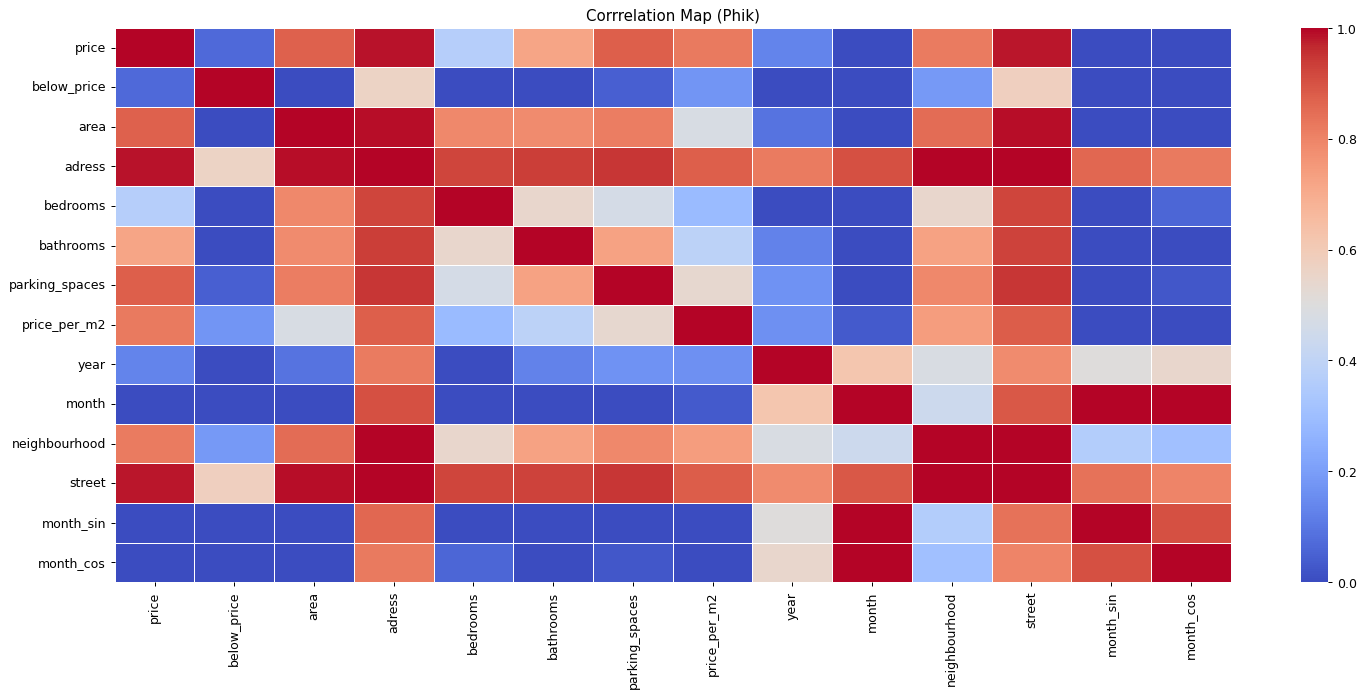

In [13]:

cols_corr = [
    'price', 'below_price', 'area', 'adress', 'bedrooms', 
    'bathrooms', 'parking_spaces', 'price_per_m2', 'year', 'month', 
    'neighbourhood', 'street', 'month_sin', 'month_cos'
]
corr = df_train.toPandas()[cols_corr].sample(1000).phik_matrix()


plot_correlation_matrix(corr)

## Clustering

In [14]:
df_train_grouped = df_train.groupBy('neighbourhood').count().orderBy('count', ascending=False)
display(df_train_grouped.limit(10).toPandas())

,neighbourhood,count
0,Jardim Paulista,901
1,Perdizes,868
2,Vila Mariana,762
3,Indianópolis,706
4,Campo Belo,588
5,Itaim Bibi,561
6,Vila Nova Conceição,476
7,Brooklin Paulista,438
8,Vila Andrade,438
9,Cerqueira César,418


In [15]:
df_test_grouped = df_test.groupBy('neighbourhood').count().orderBy('count', ascending=False)
display(df_test_grouped.limit(10).toPandas())

,neighbourhood,count
0,Jardim Paulista,212
1,Vila Mariana,205
2,Perdizes,187
3,Indianópolis,179
4,Campo Belo,150
5,Itaim Bibi,140
6,Vila Nova Conceição,134
7,Vila Olímpia,120
8,Brooklin Paulista,112
9,Moema,106


### Embeddings

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(f'{LLM_MODEL_PATH}/{LLM_MODEL_NAME}', trust_remote_code=True)
model = AutoModel.from_pretrained(f'{LLM_MODEL_PATH}/{LLM_MODEL_NAME}', trust_remote_code=True)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

model = model.to(device, dtype=torch.float32)

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Device: cuda


In [ ]:
if DIM_REDUCTION_MODEL == 'pca':
    dim_reduction_model = PCA(
        n_components=LOW_DIM,
        random_state=42
    )
elif DIM_REDUCTION_MODEL == 'umap':
    dim_reduction_model = umap.UMAP(
        n_components=LOW_DIM,   # ou 5~10 se for clusterização mais robusta
        n_neighbors=15,
        min_dist=0.1,
        random_state=42
    )
else:
    raise ValueError('Invalid DIM_REDUCTION_MODEL')

print(f'dim_reduction_model: {dim_reduction_model}')

dim_reduction_model: UMAP(random_state=42)


In [18]:
df_train_address = df_train.select(F.col('adress').alias('text'))

print(df_train_address.count())
df_train_address.limit(3).toPandas()

20851


,text
0,"Rua Pantojo , Vila Regente Feijó - São Paulo/SP"
1,"Rua Caiubi 1422, Perdizes - São Paulo/SP"
2,"Rua José Albano 219, Vila Barreto - São Paulo/SP"


In [ ]:
texts = normalize_texts(df_train_address.limit(N_MAX).rdd.map(lambda r: r[0]).collect())

embeddings = embed_texts(
    texts,
    batch_size=64
)

100%|██████████| 5213/5213 [07:59<00:00, 10.88it/s]                             


In [20]:
df_sample = df_train.limit(N_MAX).toPandas()

x_mat_emb = np.array(embeddings)
embeddings_low_dim = dim_reduction_model.fit_transform(x_mat_emb)

df_sample['text_normalized'] = texts
df_sample['embeddings'] = embeddings
df_sample['embeddings_low_dim'] = list(embeddings_low_dim)


print(f'Embedding dim: {len(embeddings[0])}')
print(f'Embedding PCA dim: {len(embeddings_low_dim[0])}')

df_sample.head(1)

Embedding dim: 1024
Embedding PCA dim: 2


,id,created_date,price,below_price,area,adress,bedrooms,bathrooms,parking_spaces,extract_date,price_per_m2,year,month,neighbourhood,street,month_sin,month_cos,text_normalized,embeddings,embeddings_low_dim
0,37948330,2018-03-27 18:20:44,1550000.0,True,315,"Rua Pantojo , Vila Regente Feijó - São Paulo/SP",3,5,4,2024-11-22,4920.634921,2018,3,Vila Regente Feijó,Rua Pantojo,1.0,6.123234e-17,"Rua Pantojo, Vila Regente Feijó - São Paulo/SP","[2.542041, 7.596713, -0.48725885, 3.486833, 4....","[-3.3084836, -5.327564]"


### Saves dimensionality reduction model

In [21]:
DIM_REDUCTION_MODEL_PATH = './models/dim_reduction_model.pkl'

with open(DIM_REDUCTION_MODEL_PATH, 'wb') as f:
    pickle.dump(dim_reduction_model, f)
    print(f'Saved dimensionality reduction model: {DIM_REDUCTION_MODEL_PATH}')

Saved dimensionality reduction model: ./models/dim_reduction_model.pkl


In [22]:
df_sample[['embedding_x', 'embedding_y']] = pd.DataFrame(
    df_sample['embeddings_low_dim'].tolist(),
    index=df_sample.index
)

In [23]:
cols = [
    'price',
    'area',
    'bedrooms',
    'bathrooms',
    'price_per_m2',
    'year',
    'month',
    'month_sin',
    'month_cos',
    'parking_spaces',
    'embedding_x',
    'embedding_y'
]

df_sample[cols].head()

,price,area,bedrooms,bathrooms,price_per_m2,year,month,month_sin,month_cos,parking_spaces,embedding_x,embedding_y
0,1550000.0,315,3,5,4920.634921,2018,3,1.0,6.123234e-17,4,-3.308484,-5.327564
1,2100000.0,202,4,5,10396.039604,2018,3,1.0,6.123234e-17,3,-10.489981,0.419245
2,399000.0,85,3,2,4694.117647,2018,3,1.0,6.123234e-17,1,-1.280107,-0.155066
3,1650000.0,160,3,1,10312.500000,2018,3,1.0,6.123234e-17,2,6.806802,4.168135
4,2400000.0,276,3,4,8695.652174,2018,3,1.0,6.123234e-17,3,6.980549,-13.917276


In [24]:
scaler = RobustScaler()

scaled_cols = [f'{col}_scaled' for col in cols]

df_sample[scaled_cols] = scaler.fit_transform(df_sample[cols])

In [25]:
df_sample[scaled_cols].head()

,price_scaled,area_scaled,bedrooms_scaled,bathrooms_scaled,price_per_m2_scaled,year_scaled,month_scaled,month_sin_scaled,month_cos_scaled,parking_spaces_scaled,embedding_x_scaled,embedding_y_scaled
0,0.150327,2.104167,0.0,1.0,-0.895815,0.0,0.0,0.0,0.0,1.0,-0.390255,-0.674643
1,0.509804,0.927083,1.0,1.0,-0.179588,0.0,0.0,0.0,0.0,0.5,-1.337054,0.095735
2,-0.601961,-0.291667,0.0,-0.5,-0.925446,0.0,0.0,0.0,0.0,-0.5,-0.122837,0.018747
3,0.215686,0.489583,0.0,-1.0,-0.190516,0.0,0.0,0.0,0.0,0.0,0.943330,0.598285
4,0.705882,1.697917,0.0,0.5,-0.402013,0.0,0.0,0.0,0.0,0.5,0.966237,-1.826120


interval columns not set, guessing: ['price_scaled', 'area_scaled', 'bedrooms_scaled', 'bathrooms_scaled', 'price_per_m2_scaled', 'year_scaled', 'month_scaled', 'month_sin_scaled', 'month_cos_scaled', 'parking_spaces_scaled', 'embedding_x_scaled', 'embedding_y_scaled']


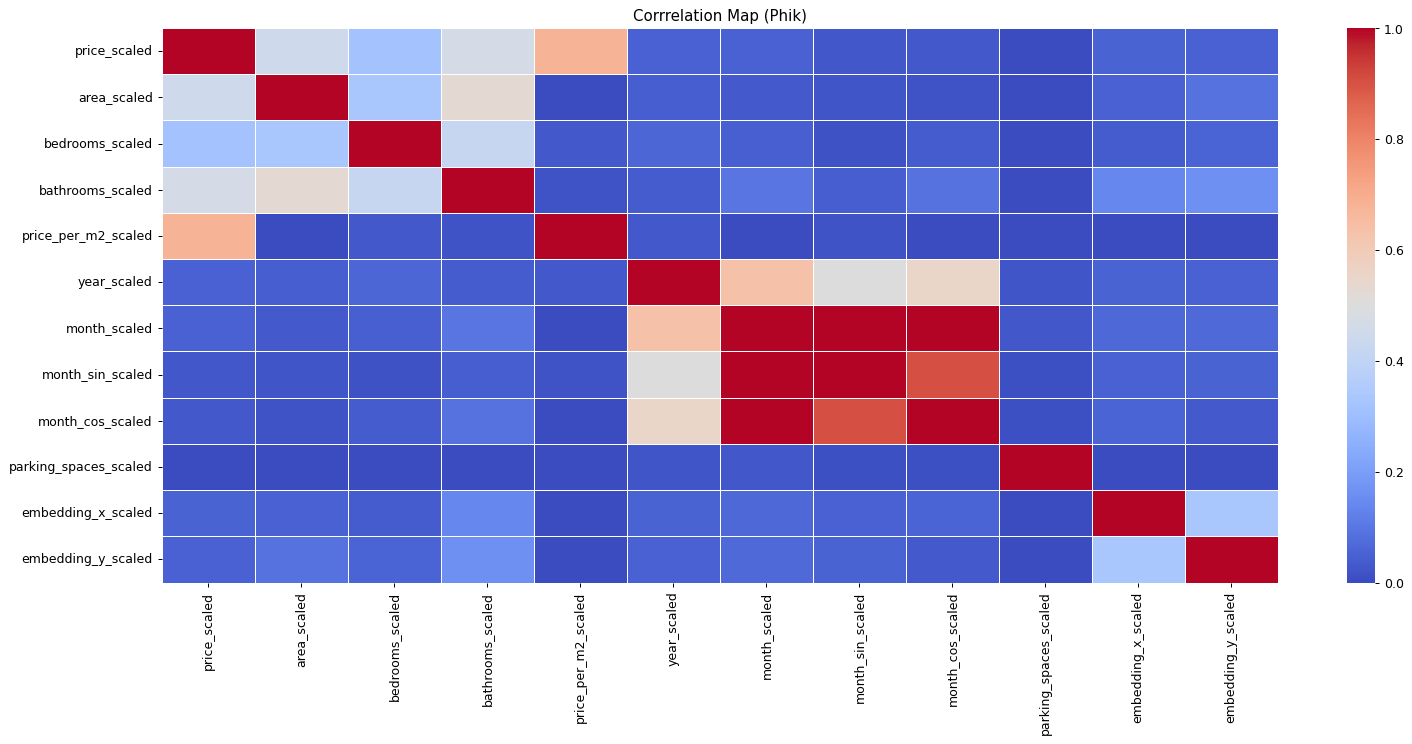

In [26]:
corr = df_sample[scaled_cols].phik_matrix()

plot_correlation_matrix(corr)

In [27]:
selected_cols = [
    'embedding_x',
    'embedding_y'
]

selected_scaled_cols = [f'{col}_scaled' for col in selected_cols]

### Select optimum k

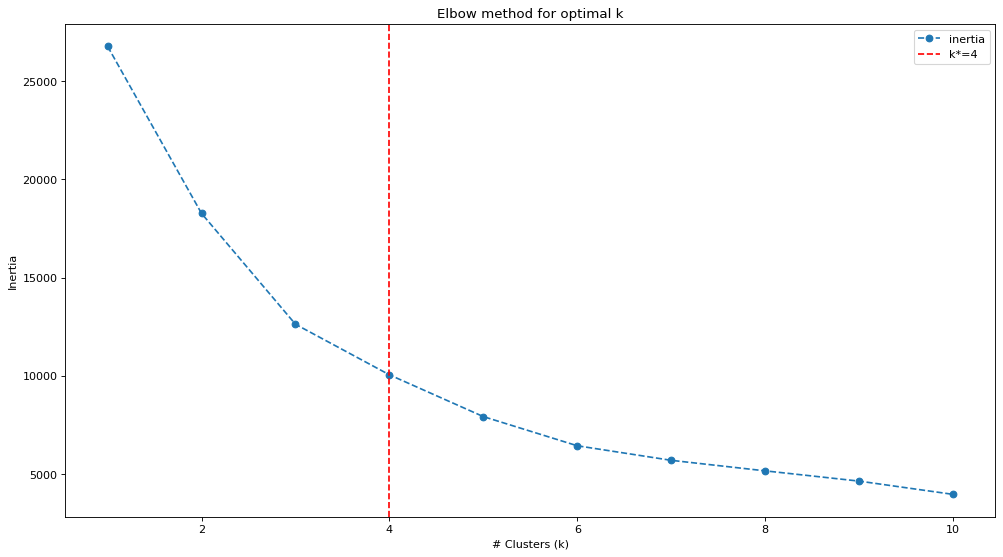

k* = 4


In [ ]:
inertia_list = []
k_candidates = range(1, 11)

for k in k_candidates:
	kmeans_model = KMeans(n_clusters=k, random_state=42)
	kmeans_model.fit(df_sample[selected_scaled_cols].values)
	inertia_list.append(kmeans_model.inertia_)

knee_loc = KneeLocator(
	k_candidates, inertia_list, curve='convex', direction='decreasing'
)
optimal_k = knee_loc.elbow
if optimal_k is None:
    optimal_k = k_candidates[len(k_candidates)//2]
    print(f'Using k* = {optimal_k}')

plt.figure(figsize=(15, 8), dpi=80)
plt.plot(k_candidates, inertia_list, marker='o',linestyle='--', label='inertia')
plt.axvline(x=optimal_k, color='r',linestyle='--', label=f'k*={optimal_k}')
plt.xlabel('# Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow method for optimal k')
plt.legend()
plt.show()

print(f'k* = {optimal_k}')

### Fitting the model

In [29]:
# # clustering_model = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clustering_model = MiniBatchKMeans(n_clusters=optimal_k, random_state=42, n_init=10)
# clustering_model = Birch(n_clusters=optimal_k)
# clustering_model = OPTICS(min_samples=10)

clustering_model.fit(df_sample[selected_scaled_cols])

labels = clustering_model.labels_

In [30]:
labels_df = pd.DataFrame({'cluster': labels})

df_cluster = df_sample.merge(
    labels_df,
    left_index=True,
    right_index=True,
    how='inner'
)

df_cluster.head()

,id,created_date,price,below_price,area,adress,bedrooms,bathrooms,parking_spaces,extract_date,...,bathrooms_scaled,price_per_m2_scaled,year_scaled,month_scaled,month_sin_scaled,month_cos_scaled,parking_spaces_scaled,embedding_x_scaled,embedding_y_scaled,cluster
0,37948330,2018-03-27 18:20:44,1550000.0,True,315,"Rua Pantojo , Vila Regente Feijó - São Paulo/SP",3,5,4,2024-11-22,...,1.0,-0.895815,0.0,0.0,0.0,0.0,1.0,-0.390255,-0.674643,2
1,39560479,2018-03-27 14:12:45,2100000.0,False,202,"Rua Caiubi 1422, Perdizes - São Paulo/SP",4,5,3,2024-11-22,...,1.0,-0.179588,0.0,0.0,0.0,0.0,0.5,-1.337054,0.095735,0
2,48017739,2018-03-27 16:42:07,399000.0,True,85,"Rua José Albano 219, Vila Barreto - São Paulo/SP",3,2,1,2024-11-22,...,-0.5,-0.925446,0.0,0.0,0.0,0.0,-0.5,-0.122837,0.018747,0
3,50235054,2018-03-27 14:06:14,1650000.0,False,160,"Rua Cardoso de Almeida 1116, Perdizes - São Pa...",3,1,2,2024-11-22,...,-1.0,-0.190516,0.0,0.0,0.0,0.0,0.0,0.943330,0.598285,3
4,51102181,2018-03-27 12:55:57,2400000.0,False,276,"Rua Volta Redonda , Campo Belo - São Paulo/SP",3,4,3,2024-11-22,...,0.5,-0.402013,0.0,0.0,0.0,0.0,0.5,0.966237,-1.826120,1


In [ ]:
df_plot = df_cluster[scaled_cols + ['cluster'] ].copy()

## Visualize clustering results

In [33]:
df_plot.shape

(20851, 13)

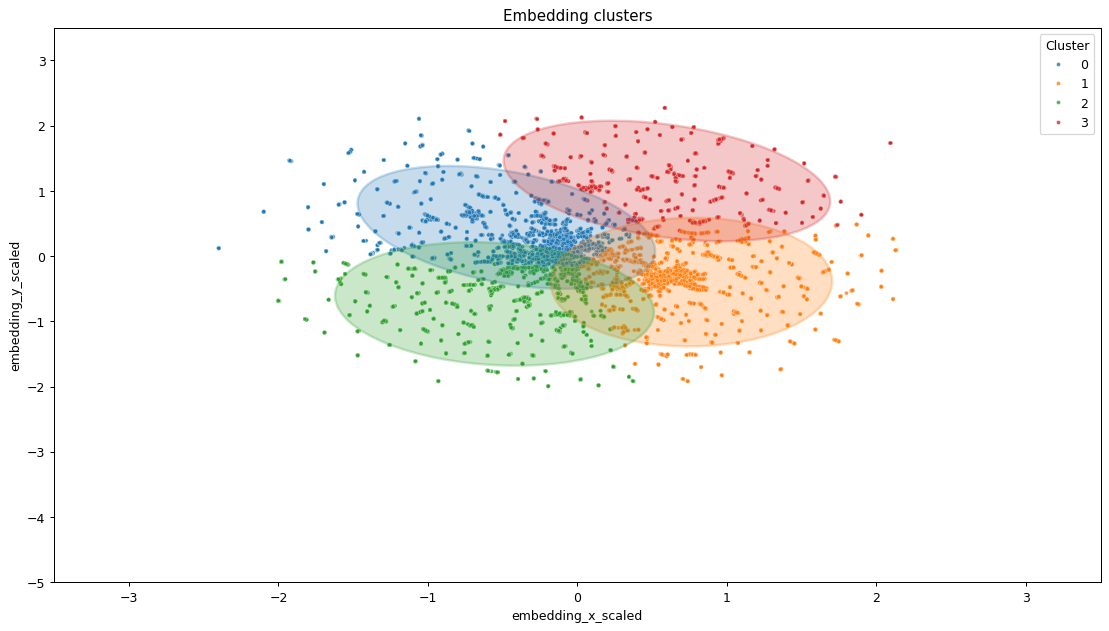

In [ ]:
scatter_plot_clusters(
    df_plot,
    graph_title='Embedding clusters',
    xlim = (-3.5, 3.5),
    ylim = (-5.0, 3.5)
)

## Metrics

In [35]:
df_plot[scaled_cols].describe()

,price_scaled,area_scaled,bedrooms_scaled,bathrooms_scaled,price_per_m2_scaled,year_scaled,month_scaled,month_sin_scaled,month_cos_scaled,parking_spaces_scaled,embedding_x_scaled,embedding_y_scaled
count,20851.000000,20851.000000,20851.000000,20851.000000,20851.000000,20851.000000,20851.000000,20851.000000,20851.000000,20851.000000,20851.000000,20851.000000
mean,0.471897,0.241507,-0.255288,-0.076975,0.255756,0.486979,0.425267,-0.508529,-0.043857,0.080572,0.039241,0.042726
std,1.952099,0.941868,0.920122,0.713873,1.851493,0.692432,0.701240,0.745412,0.448252,1.640373,0.790252,0.812316
min,-0.790850,-1.072917,-2.000000,-1.000000,-1.510981,0.000000,-0.500000,-2.000000,-1.000000,-0.500000,-2.399470,-1.993869
25%,-0.359477,-0.406250,-1.000000,-0.500000,-0.418262,0.000000,0.000000,-1.000000,0.000000,-0.500000,-0.434425,-0.459833
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.640523,0.593750,0.000000,0.500000,0.581738,1.000000,1.000000,0.000000,0.000000,0.500000,0.565575,0.540167
max,78.894763,19.864583,17.000000,4.500000,181.936132,2.000000,2.250000,0.000000,1.000000,174.000000,2.136405,2.272701


In [36]:
x_scaled = df_plot[selected_scaled_cols].values.copy()
labels = df_plot['cluster'].values

compute_metrics(x_scaled, labels, 'train')

,silhouette_score_train,calinski_harabasz_score_train,davies_bouldin_score_train
metrics,0.318467,11521.756637,0.997261


## Apply the model to the test set

In [37]:
df_test.count()

5201

In [38]:
df_test.limit(1).toPandas()

,id,created_date,price,below_price,area,adress,bedrooms,bathrooms,parking_spaces,extract_date,price_per_m2,year,month,neighbourhood,street,month_sin,month_cos
0,44326867,2018-03-27 14:06:14,3200000.0,True,288,"Rua Alagoas 710, Higienópolis - São Paulo/SP",3,1,4,2024-11-22,11111.111111,2018,3,Higienópolis,Rua Alagoas 710,1.0,6.123234e-17


In [ ]:
df_test_address = df_test.select(F.col('adress').alias('text'))

texts = normalize_texts(df_test_address.limit(N_MAX).rdd.map(lambda r: r[0]).collect())

embeddings = embed_texts(
    texts,
    batch_size=64
)

100%|██████████| 1301/1301 [02:00<00:00, 10.84it/s]


In [ ]:
df_sample_test = df_test.limit(N_MAX).toPandas()

x_mat_emb = np.array(embeddings)
embeddings_low_dim = dim_reduction_model.transform(x_mat_emb)

df_sample_test['text_normalized'] = texts
df_sample_test['embeddings'] = embeddings
df_sample_test['embeddings_low_dim'] = list(embeddings_low_dim)


print(f'Embedding dim: {len(embeddings[0])}')
print(f'Embedding PCA dim: {len(embeddings_low_dim[0])}')

display(df_sample_test.head(1))


df_sample_test[['embedding_x', 'embedding_y']] = pd.DataFrame(
    df_sample_test['embeddings_low_dim'].tolist(),
    index=df_sample_test.index
)

df_sample_test[scaled_cols] = scaler.transform(df_sample_test[cols])

labels = clustering_model.predict(df_sample_test[selected_scaled_cols])

labels_df = pd.DataFrame({'cluster': labels})

df_cluster_test= df_sample_test.merge(
    labels_df,
    left_index=True,
    right_index=True,
    how='inner'
)

display(df_cluster_test.head(1))

df_plot_test = df_cluster_test[scaled_cols + ['cluster'] ].copy()

df_plot_test[['embedding_x_scaled', 'embedding_y_scaled', 'cluster']].head(1)

Embedding dim: 1024
Embedding PCA dim: 2


,id,created_date,price,below_price,area,adress,bedrooms,bathrooms,parking_spaces,extract_date,price_per_m2,year,month,neighbourhood,street,month_sin,month_cos,text_normalized,embeddings,embeddings_low_dim
0,44326867,2018-03-27 14:06:14,3200000.0,True,288,"Rua Alagoas 710, Higienópolis - São Paulo/SP",3,1,4,2024-11-22,11111.111111,2018,3,Higienópolis,Rua Alagoas 710,1.0,6.123234e-17,"Rua Alagoas 710, Higienópolis - São Paulo/SP","[2.7790618, 6.617949, -0.49921364, 5.1201215, ...","[1.96064, -8.47171]"


,id,created_date,price,below_price,area,adress,bedrooms,bathrooms,parking_spaces,extract_date,...,bathrooms_scaled,price_per_m2_scaled,year_scaled,month_scaled,month_sin_scaled,month_cos_scaled,parking_spaces_scaled,embedding_x_scaled,embedding_y_scaled,cluster
0,44326867,2018-03-27 14:06:14,3200000.0,True,288,"Rua Alagoas 710, Higienópolis - São Paulo/SP",3,1,4,2024-11-22,...,-1.0,-0.086051,0.0,0.0,0.0,0.0,1.0,0.304419,-1.096125,1


,embedding_x_scaled,embedding_y_scaled,cluster
0,0.304419,-1.096125,1


In [41]:
x_scaled_test = df_plot_test[selected_scaled_cols].values.copy()
labels_test = df_plot_test['cluster'].values

compute_metrics(x_scaled_test, labels_test, 'test')

,silhouette_score_test,calinski_harabasz_score_test,davies_bouldin_score_test
metrics,0.317927,2787.106528,1.007223


In [42]:
df_plot_test.shape

(5201, 13)

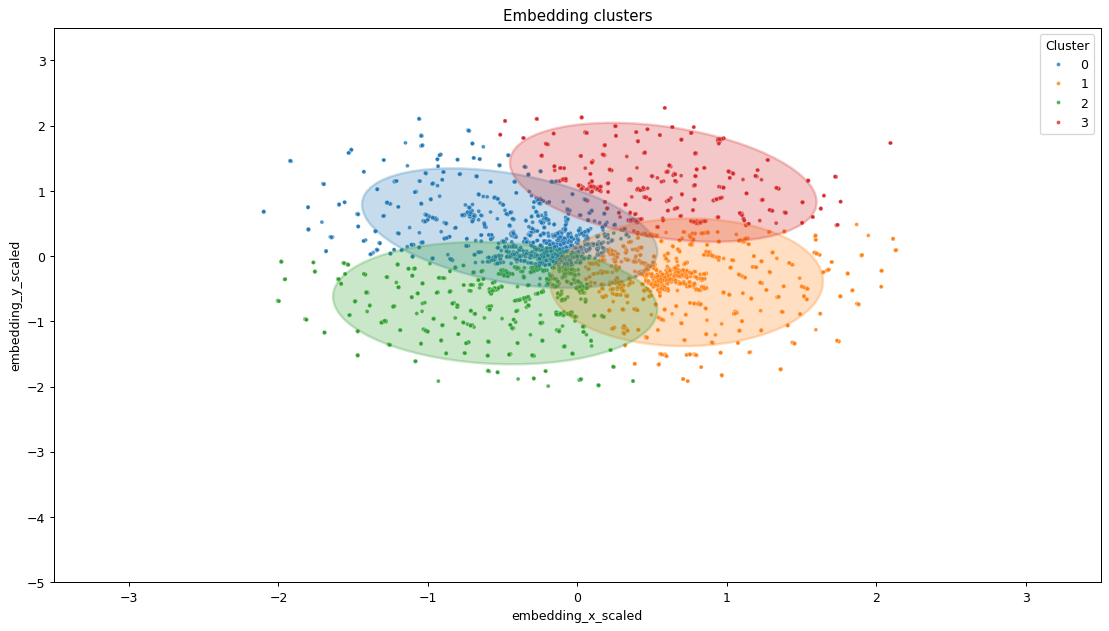

In [ ]:
scatter_plot_clusters(
    df_plot_test, graph_title='Embedding clusters',
    xlim = (-3.5, 3.5), ylim = (-5.0, 3.5)
)

In [44]:
df_cluster_test_grouped = (
    df_cluster_test
    .groupby(by=['cluster', 'neighbourhood'])
    .count()
    .sort_values('id', ascending=False)
)[['id']].reset_index(drop=False)

df_cluster_test_grouped.head(10)

,cluster,neighbourhood,id
0,1,Jardim Paulista,131
1,0,Vila Mariana,122
2,0,Vila Nova Conceição,85
3,3,Perdizes,81
4,3,Brooklin Paulista,71
5,1,Indianópolis,70
6,3,Santo Amaro,69
7,0,Vila Olímpia,67
8,2,Paraíso,59
9,0,Jardim Paulista,58


In [45]:
df_cluster_test.head(1)

,id,created_date,price,below_price,area,adress,bedrooms,bathrooms,parking_spaces,extract_date,...,bathrooms_scaled,price_per_m2_scaled,year_scaled,month_scaled,month_sin_scaled,month_cos_scaled,parking_spaces_scaled,embedding_x_scaled,embedding_y_scaled,cluster
0,44326867,2018-03-27 14:06:14,3200000.0,True,288,"Rua Alagoas 710, Higienópolis - São Paulo/SP",3,1,4,2024-11-22,...,-1.0,-0.086051,0.0,0.0,0.0,0.0,1.0,0.304419,-1.096125,1


## Intra-cluster analyses



█████████████████████████████████████████████████████████████████████████████████
████████████████████████████████ INFOS CLUSTER 0 ████████████████████████████████
█████████████████████████████████████████████████████████████████████████████████

▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄ ↗︎ 5 maiores preços médios por m² (cluster 0) ▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄


,cluster,neighbourhood,mean_price_per_m2,mean_price,mean_area,mean_bedrooms,mean_bathrooms,mean_parking_spaces
498,0,Jardim América,27387.73,4430843,149.14,2.43,3.29,1.86
2,0,Vila Nova Conceição,25765.32,4905897,167.41,2.53,3.19,2.49
7,0,Vila Olímpia,22666.80,2992051,112.43,2.17,2.71,2.05
17,0,Itaim Bibi,20572.62,3351153,154.33,2.54,2.88,2.19
547,0,Vila Cosmopolita,20427.40,204274,10.00,2.00,1.00,1.00


▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄ ↘︎ 5 menores preços médios por m² (cluster 0) ▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄


,cluster,neighbourhood,mean_price_per_m2,mean_price,mean_area,mean_bedrooms,mean_bathrooms,mean_parking_spaces
583,0,Chácara Santa Maria,3538.46,230000,65.0,3.0,1.0,1.0
491,0,Jaraguá,3365.50,332500,99.0,2.5,1.0,1.0
467,0,Vila Missionária,3294.87,257000,78.0,2.0,1.0,2.0
731,0,Jardim Cláudia,2990.00,299000,100.0,2.0,1.0,1.0
470,0,Cidade Tiradentes,2173.91,100000,46.0,2.0,1.0,2.0



▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄ Analyses (🤖) ▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄


Here's a concise analysis of the performance metrics in bullet points:

* **Neighborhood Variance**: The data shows properties from different neighborhoods, including Chácara Santa Maria, Jaraguá, Vila Missionária, Jardim Cláudia, and Cidade Tiradentes, indicating varying property values across locations.
* **Price Disparity**: The mean price per square meter ranges from 2,173.91 to 3,538.46, with a significant difference between the cheapest (Cidade Tiradentes) and most expensive (Chácara Santa Maria) areas.
* **Property Size and Features**: The mean area, bedrooms, bathrooms, and parking spaces vary across properties, with the most expensive area (Chácara Santa Maria) having smaller properties (65.0 square meters) and the largest properties (100.0 square meters) found in Jaraguá and Jardim Cláudia.
* **Pricing Trends**: The mean price of properties ranges from 100,000 to 332,500, with the most expensive properties found in Jaraguá and the cheapest in Cidade Tiradentes.
* **Key Factors Influencing Price**: The data suggests that neighborhood, property size, and features (such as number of bedrooms and parking spaces) are key factors influencing property prices.

Conclusion: The performance metrics indicate significant variations in property prices, sizes, and features across different neighborhoods. The most expensive properties are found in Jaraguá, while

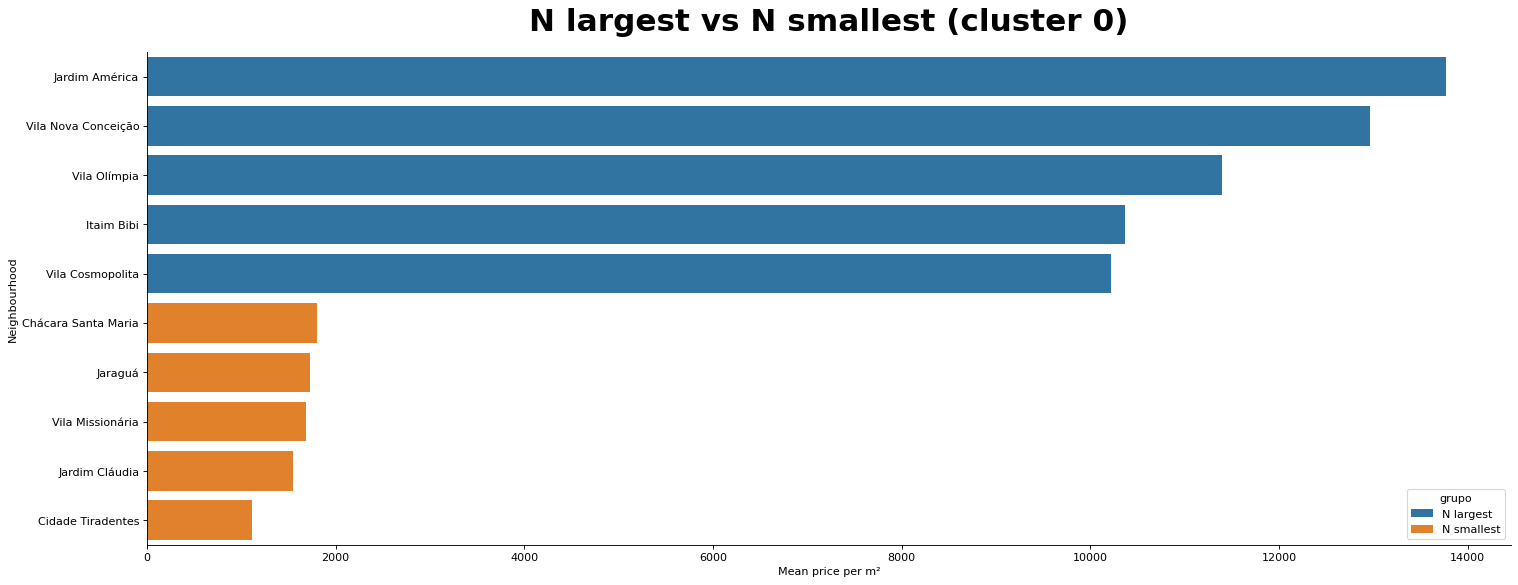

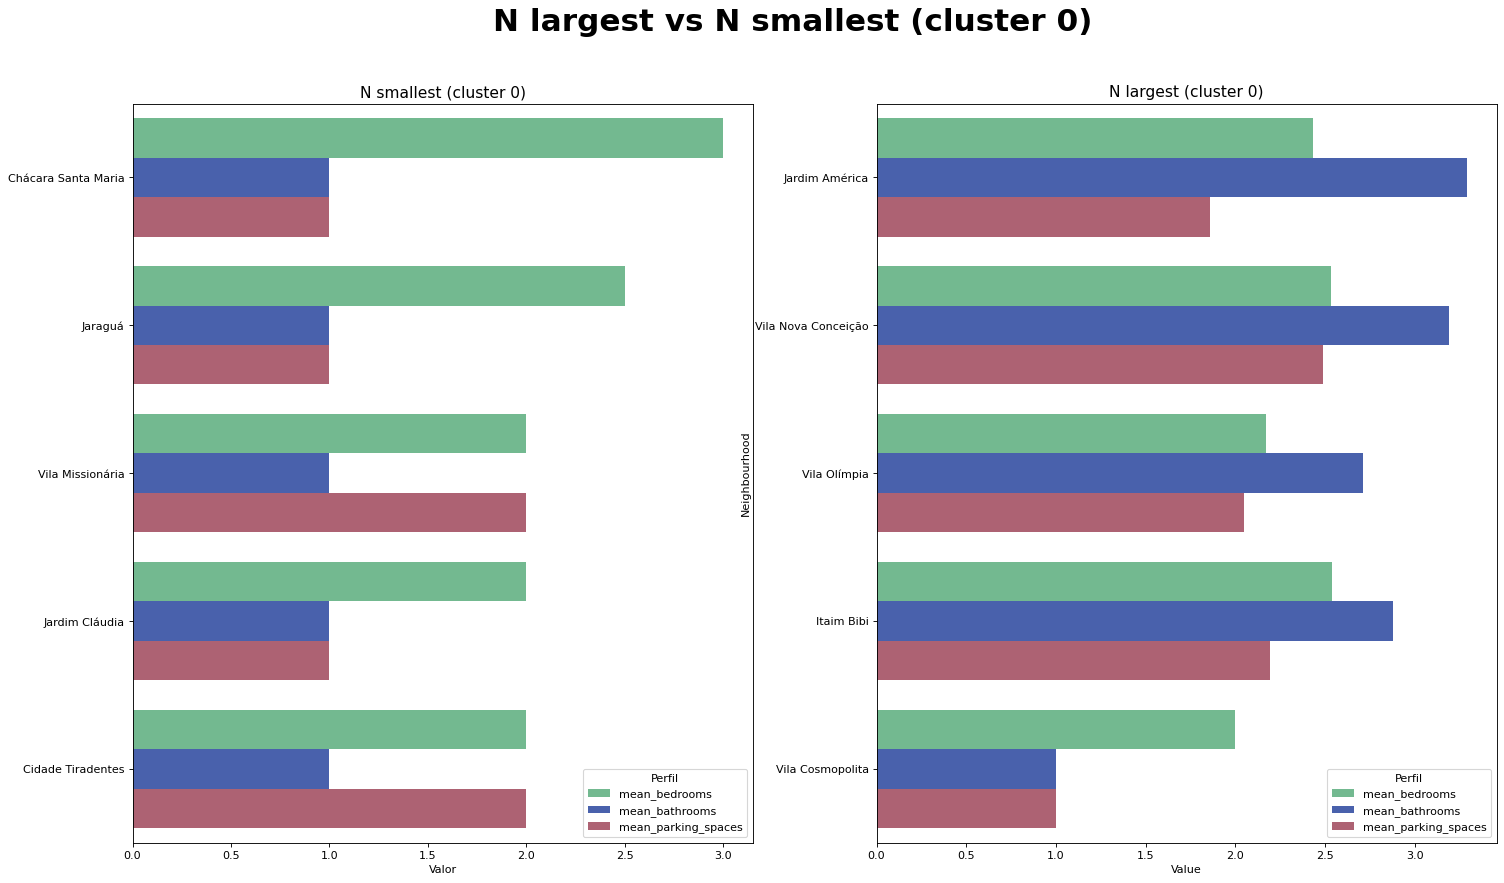

░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░


█████████████████████████████████████████████████████████████████████████████████
████████████████████████████████ INFOS CLUSTER 1 ████████████████████████████████
█████████████████████████████████████████████████████████████████████████████████

▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄ ↗︎ 5 maiores preços médios por m² (cluster 1) ▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄


,cluster,neighbourhood,mean_price_per_m2,mean_price,mean_area,mean_bedrooms,mean_bathrooms,mean_parking_spaces
286,1,Jardim Panorama (Zona Oeste),45205.56,12591000,288.33,3.33,3.67,4.00
164,1,Jardim Panorama,41790.98,15295143,322.86,3.14,4.29,4.57
650,1,Vila Caraguatá,33477.68,7499000,224.00,4.00,4.00,3.00
54,1,Jardim Europa,33433.41,10255964,242.72,3.00,3.68,2.96
408,1,Cidade Jardim,28111.58,4530000,168.50,2.00,4.00,3.00


▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄ ↘︎ 5 menores preços médios por m² (cluster 1) ▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄


,cluster,neighbourhood,mean_price_per_m2,mean_price,mean_area,mean_bedrooms,mean_bathrooms,mean_parking_spaces
331,1,Vila Sílvia,4116.59,271250,68.5,2.5,1.0,1.0
344,1,Jaçanã,3801.77,324000,86.0,3.0,1.5,1.0
656,1,Jardim Marilu,3620.04,181002,50.0,2.0,1.0,2.0
709,1,Jaraguá,3365.50,332500,99.0,2.5,1.0,1.0
531,1,Jardim São Paulo(Zona Leste),1528.00,191000,125.0,2.0,2.0,8.0



▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄ Analyses (🤖) ▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄


Here's a concise analysis of the performance metrics in bullet points:

* **Neighborhood Variance**: The data covers properties in different neighborhoods, including Vila Sílvia, Jaçanã, Jardim Marilu, Jaraguá, and Jardim São Paulo(Zona Leste), indicating a diverse range of locations.
* **Price Disparity**: The mean price per square meter varies significantly, with the highest being 4116.59 in Vila Sílvia (331) and the lowest being 1528.0 in Jardim São Paulo(Zona Leste) (531), showing a substantial difference in property values.
* **Property Characteristics**: The mean area, bedrooms, bathrooms, and parking spaces also vary across properties, with the largest mean area being 125.0 in Jardim São Paulo(Zona Leste) (531) and the most parking spaces being 8.0 in the same neighborhood.
* **Cluster Consistency**: All properties are assigned to cluster 1, indicating that the model has grouped them together based on similar characteristics or patterns.
* **Key Factors Influencing Price**:
  + Location (neighborhood)
  + Property size (mean area)
  + Number of bedrooms and bathrooms
  + Parking spaces
* **Conclusion**: The model has identified significant differences in property prices and characteristics across various neighborhoods. The most expensive properties are located in Vila Sílvia, while the cheapest ones are in Jard

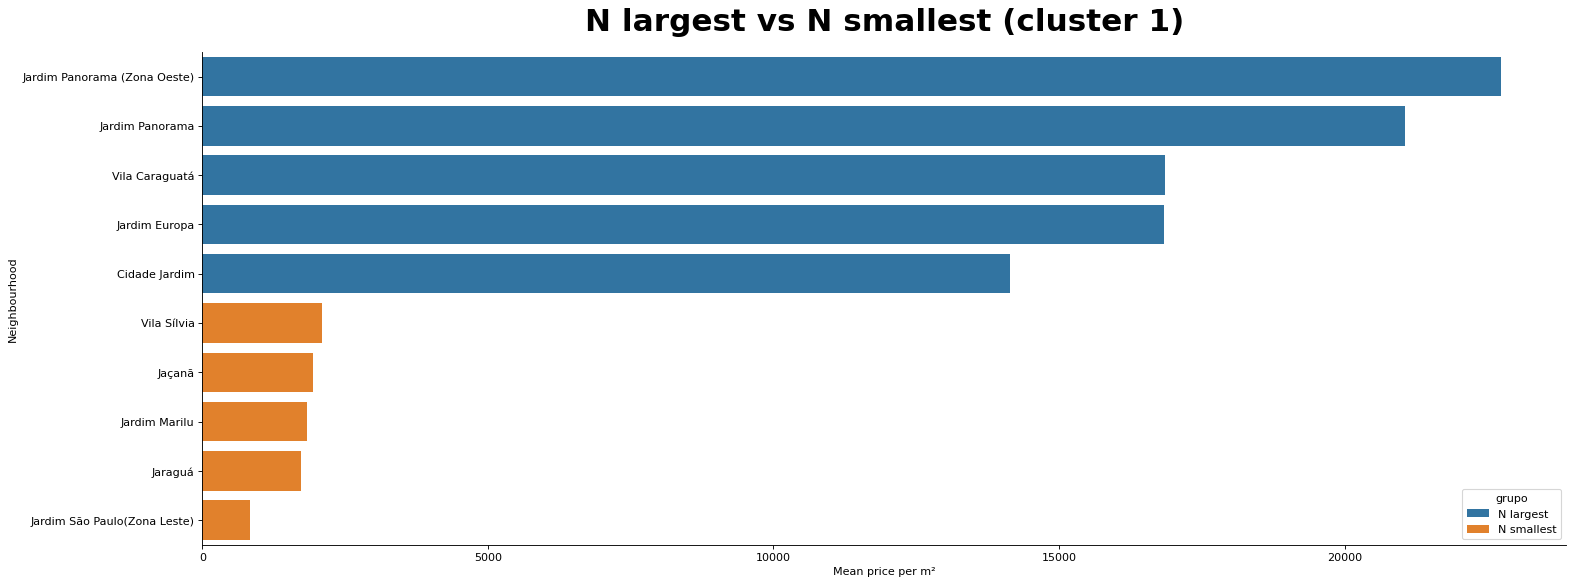

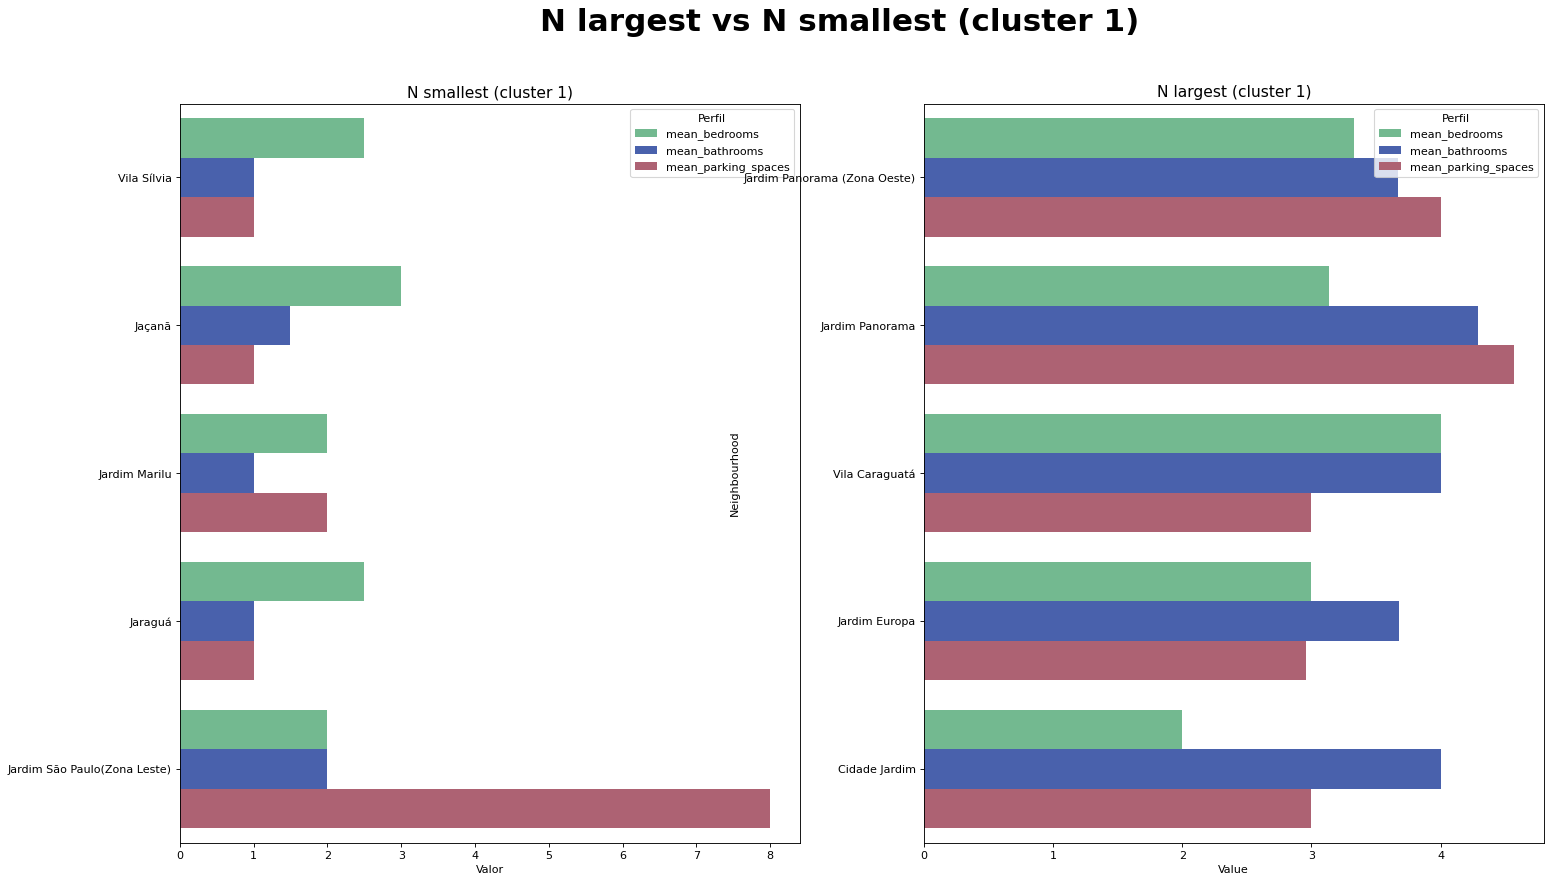

░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░


█████████████████████████████████████████████████████████████████████████████████
████████████████████████████████ INFOS CLUSTER 2 ████████████████████████████████
█████████████████████████████████████████████████████████████████████████████████

▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄ ↗︎ 5 maiores preços médios por m² (cluster 2) ▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄


,cluster,neighbourhood,mean_price_per_m2,mean_price,mean_area,mean_bedrooms,mean_bathrooms,mean_parking_spaces
678,2,Jardim Paulistano,26370.73,10267742,311.67,3.33,2.67,3.67
254,2,São Judas,26333.31,1891761,69.25,2.50,1.75,1.75
20,2,Vila Nova Conceição,25765.32,4905897,167.41,2.53,3.19,2.49
671,2,Jardim Paulistano (Zona Oeste),24804.68,4158167,161.67,2.00,2.67,1.83
51,2,Vila Olímpia,22666.80,2992051,112.43,2.17,2.71,2.05


▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄ ↘︎ 5 menores preços médios por m² (cluster 2) ▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄


,cluster,neighbourhood,mean_price_per_m2,mean_price,mean_area,mean_bedrooms,mean_bathrooms,mean_parking_spaces
325,2,Jardim Santa Emília,5012.39,265000,54.67,2.67,1.0,1.0
384,2,Jardim Bélgica,4799.27,1972500,411.00,4.00,6.0,3.0
468,2,Vila Pires,4642.86,520000,112.00,3.00,2.0,2.0
363,2,Jardim Peri,4546.91,245000,54.00,2.00,1.0,1.0
689,2,Jardim Planalto,3872.73,213000,55.00,2.00,1.0,1.0



▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄ Analyses (🤖) ▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄


Here's a concise analysis of the performance metrics in bullet points:

* **Price Variation**: The mean price per square meter ranges from 3,872.73 to 5,012.39, indicating a significant difference in property prices across neighborhoods.
* **Neighborhood Impact**: The neighborhood with the highest mean price per square meter is 'Jardim Santa Emília' (5,012.39), while the lowest is 'Jardim Planalto' (3,872.73).
* **Property Size and Features**: Larger properties with more bedrooms, bathrooms, and parking spaces tend to be more expensive, as seen in the 'Jardim Bélgica' neighborhood with a mean area of 411.0 square meters and a mean price of 1,972,500.
* **Cluster Analysis**: The cluster analysis shows that properties with similar characteristics are grouped together, with 2 clusters having similar mean prices and features.
* **Key Drivers of Price**: The mean price per square meter is influenced by factors such as neighborhood, property size, number of bedrooms and bathrooms, and parking spaces.

Conclusion: The performance metrics suggest that property prices are influenced by a combination of factors, including neighborhood, property size, and features. The model can be used to identify key drivers of price and predict property prices based on these factors.

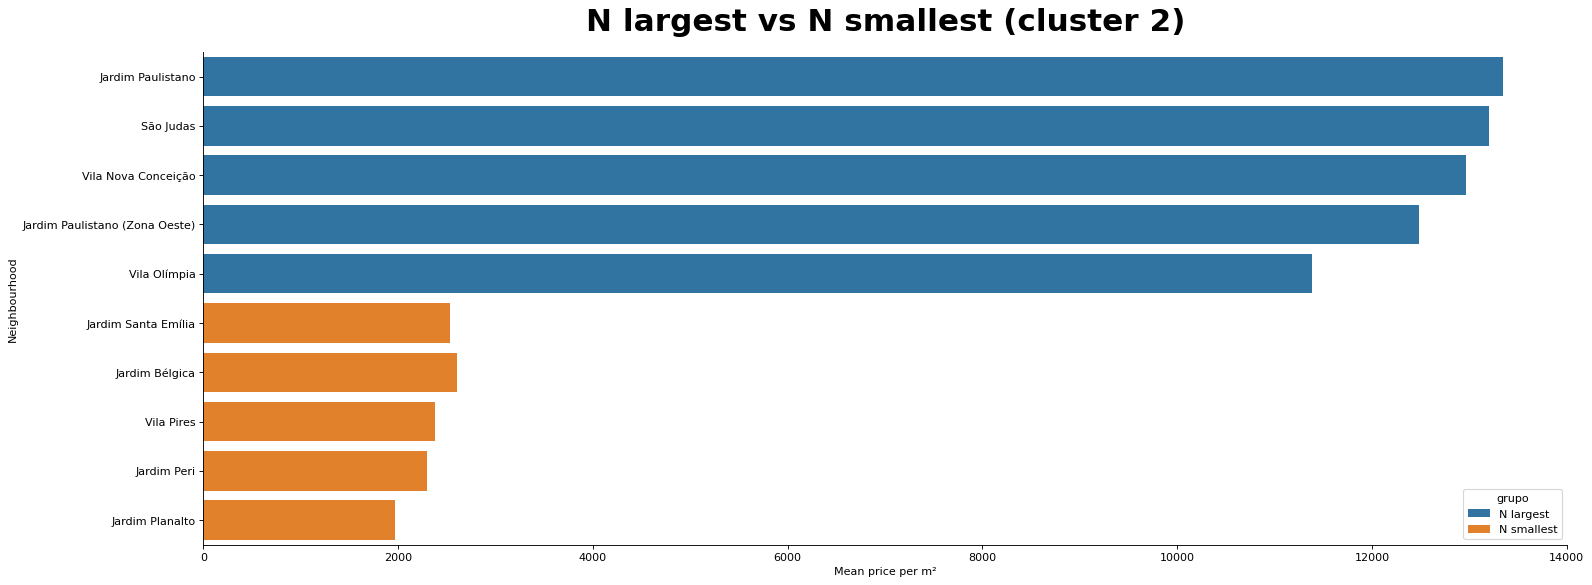

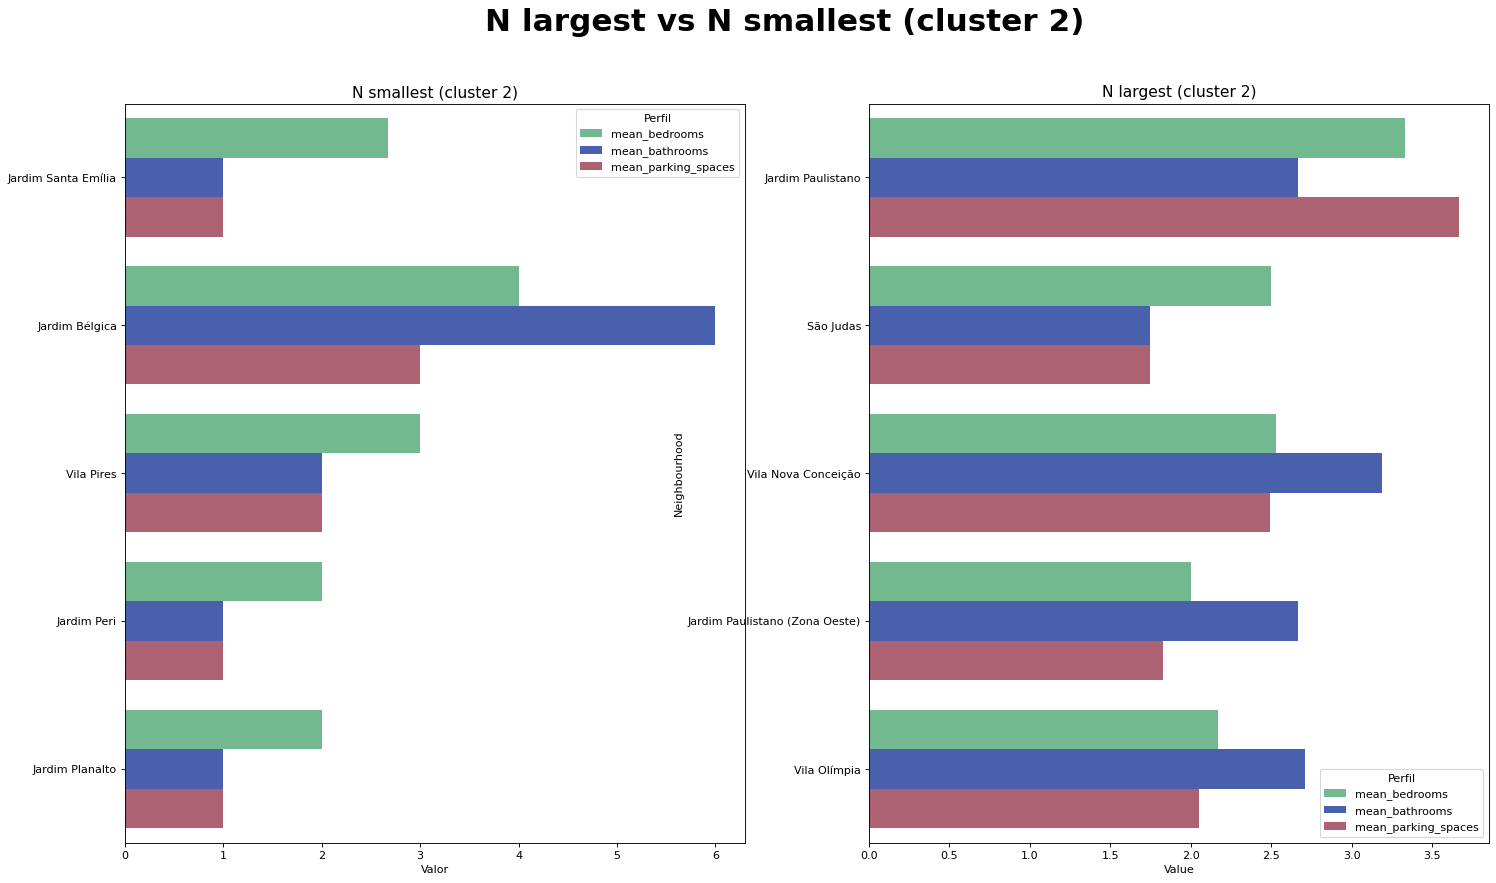

░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░


█████████████████████████████████████████████████████████████████████████████████
████████████████████████████████ INFOS CLUSTER 3 ████████████████████████████████
█████████████████████████████████████████████████████████████████████████████████

▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄ ↗︎ 5 maiores preços médios por m² (cluster 3) ▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄


,cluster,neighbourhood,mean_price_per_m2,mean_price,mean_area,mean_bedrooms,mean_bathrooms,mean_parking_spaces
312,3,Ibirapuera,46600.98,12273697,261.00,3.33,5.00,4.00
243,3,Vila Nova Conceição,25765.32,4905897,167.41,2.53,3.19,2.49
76,3,Vila Olímpia,22666.80,2992051,112.43,2.17,2.71,2.05
12,3,Itaim Bibi,20572.62,3351153,154.33,2.54,2.88,2.19
92,3,Cerqueira César,20143.61,3978246,220.08,2.68,2.92,2.22


▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄ ↘︎ 5 menores preços médios por m² (cluster 3) ▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄


,cluster,neighbourhood,mean_price_per_m2,mean_price,mean_area,mean_bedrooms,mean_bathrooms,mean_parking_spaces
549,3,Vila Bela Vista (Zona Norte),5936.17,279000,47.0,2.0,1.0,1.0
524,3,Parque Santo Antônio,5400.00,270000,50.0,3.0,1.0,1.0
342,3,Jardim Germânia,4968.25,461500,101.5,3.0,1.0,1.5
533,3,Jardim Alvorada (Zona Sul),4488.32,350089,78.0,3.0,1.0,1.0
586,3,Conjunto Habitacional Barreira Grande,3709.68,230000,62.0,3.0,1.0,1.0



▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄ Analyses (🤖) ▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄


Here's a concise analysis of the performance metrics in bullet points:

* **Neighborhood Variance**: Properties are located in different neighborhoods, such as Vila Bela Vista, Parque Santo Antônio, and Jardim Germânia, which may impact pricing due to factors like proximity to amenities, transportation, and local demand.
* **Price per Square Meter**: The mean price per square meter ranges from 3709.68 to 5936.17, indicating a significant difference in property values across locations.
* **Property Size and Layout**: Mean area ranges from 47.0 to 101.5 square meters, with most properties having 3 bedrooms and 1 bathroom, suggesting that larger properties or those with more amenities may command higher prices.
* **Cluster Assignment**: All properties are assigned to cluster 3, which may indicate similar characteristics or market trends among these properties.
* **Pricing Disparities**: Mean prices range from 230,000 to 461,500, with significant variations in price per square meter, suggesting that factors like location, property size, and amenities contribute to these disparities.

Conclusion: The performance metrics suggest that location, property size, and amenities are key drivers of pricing differences among these properties. The significant variation in price per square meter and mean prices across neighborhoods highlights the importance of considering local market conditions and property characteristics when evaluating rents pricing.

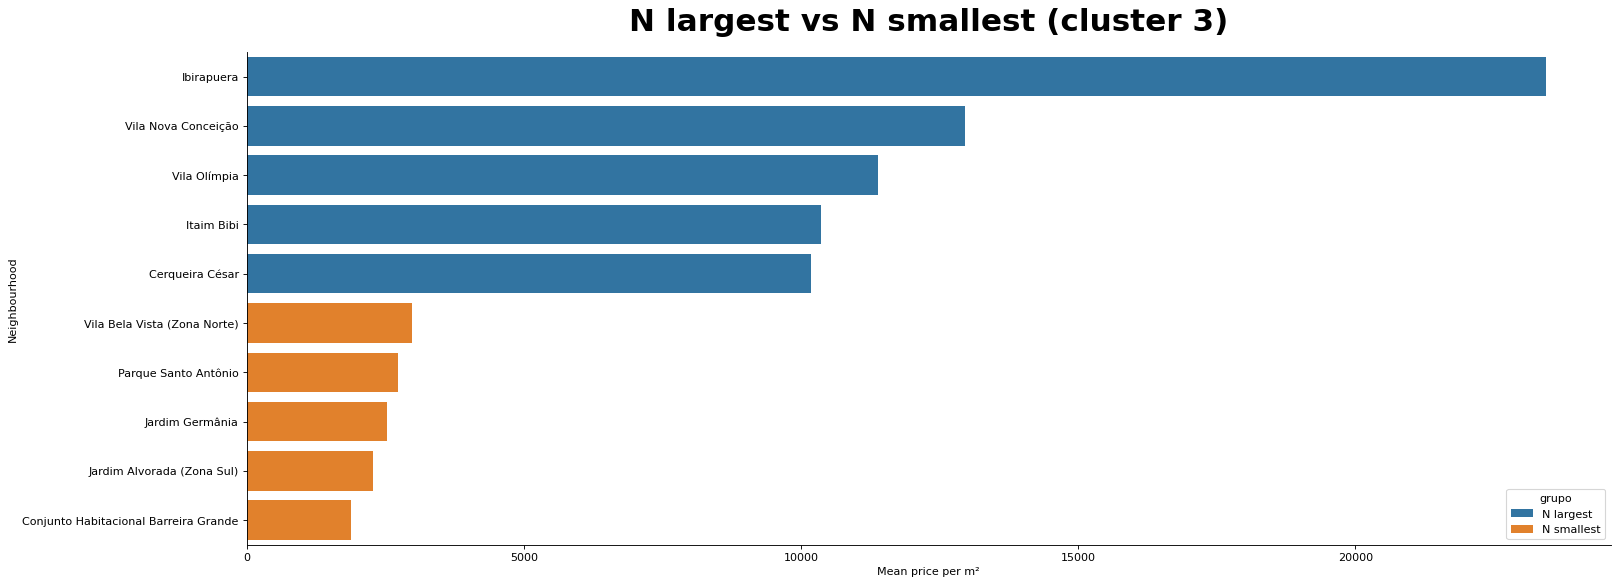

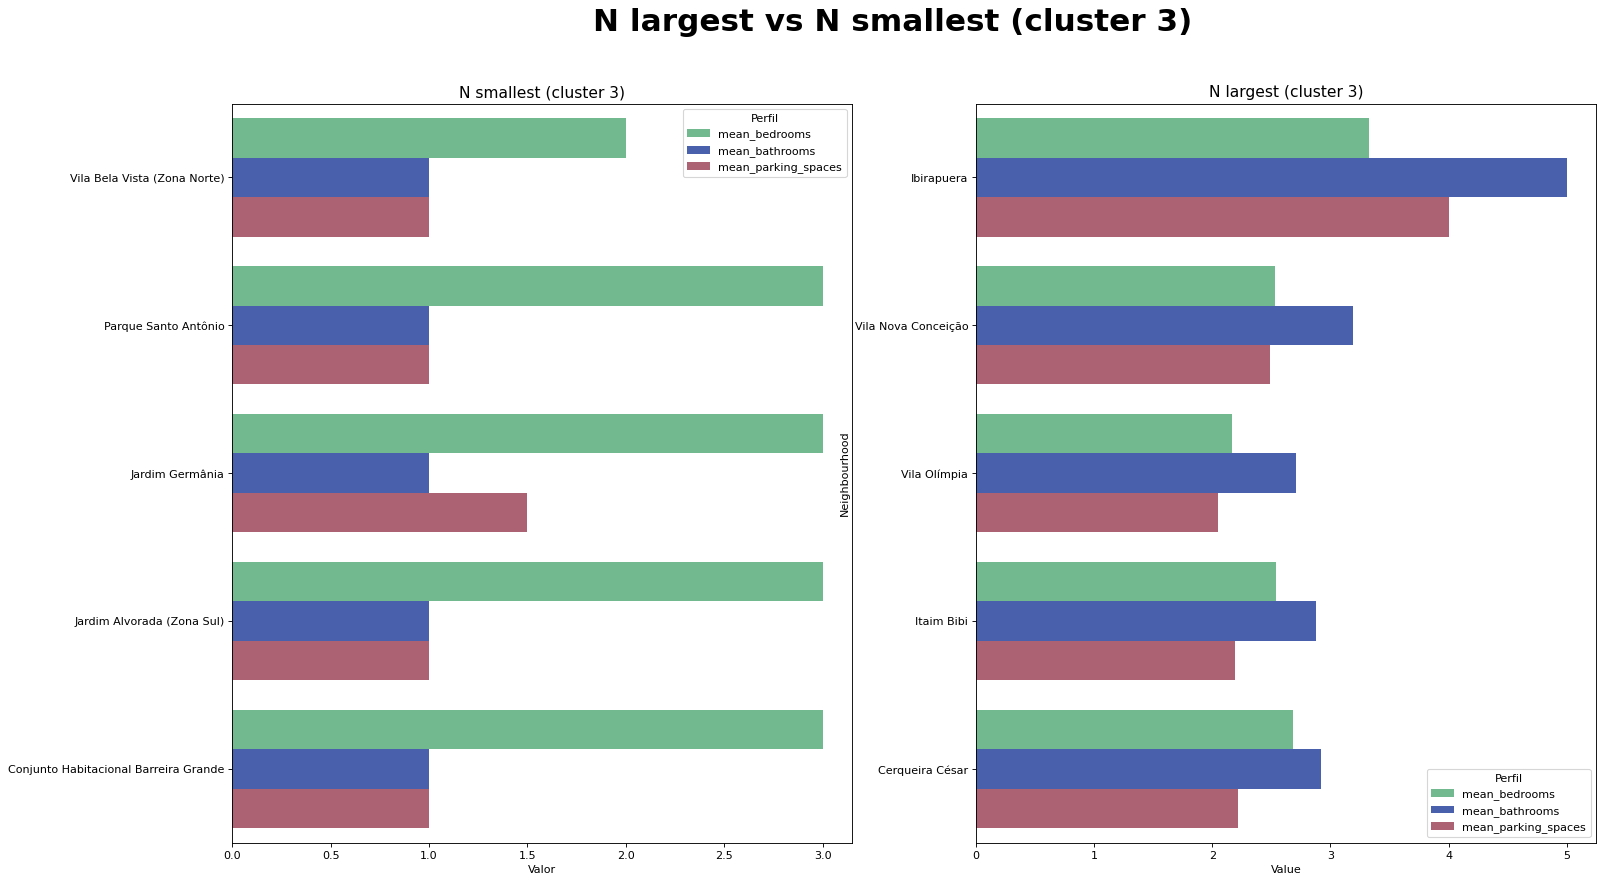

░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░


In [48]:
clusters_list = sorted(df_cluster_test.cluster.unique(), reverse=False)

for i in clusters_list:
    print(f'\n\n█████████████████████████████████████████████████████████████████████████████████')
    print(f'████████████████████████████████ INFOS CLUSTER {i} ████████████████████████████████')
    print(f'█████████████████████████████████████████████████████████████████████████████████\n')
    
    df_group_cluster_nlargest, df_group_cluster_nsmallest = describe_cluster(df_grouped=df_cluster_test_grouped, cluster_i=i)

    explain_results(
        {**df_group_cluster_nlargest.to_dict(), **df_group_cluster_nsmallest.to_dict()}
    )

    plot_comparison_mean_price_per_m2(
        df_nlargest=df_group_cluster_nlargest,
        df_nsmallest=df_group_cluster_nsmallest,
        cluster_i=i
    )

    plot_comparison_perfil(
        df_nlargest=df_group_cluster_nlargest,
        df_nsmallest=df_group_cluster_nsmallest,
        cluster_i=i
    )
    print(100*'░')